In [11]:
# ===================================================
# Import dependencies, config, and define constants
# ===================================================

import sys
import os
sys.path.append(os.path.abspath("../src"))

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils.io_utils import load_csv_folder
from utils.io_utils import load_config


from utils.preprocess_utils import extract_base_freethrow_name
from utils.preprocess_utils import combine_angles_dfs
from utils.preprocess_utils import filter_angles_kalman
from utils.preprocess_utils import crop_to_freethrow

from utils.align_freethrows_utils import align_by_lowest_frame
from utils.align_freethrows_utils import align_by_release_frame
from utils.align_freethrows_utils import align_by_min_unsigned_area
from utils.align_freethrows_utils import align_by_min_signed_area
from utils.align_freethrows_utils import apply_shift_to_dataset

from utils.freethrow_stats_utils import compute_mean_std_for_alignment

from utils.analyze_freethrows_utils import analyze_freethrow_durations
from utils.analyze_freethrows_utils import analyze_release_timing
from utils.analyze_freethrows_utils import analyze_release_angles

from utils.visualize_freethrow_utils import FreeThrowVisualizer

project_cfg = load_config("project_config.yaml")
ATHLETE = project_cfg["athlete"]
SESSION = project_cfg["session"]

# existing paths
metrics_dir = Path(f"../data/{ATHLETE}/{SESSION}/metrics")
calibration_dir = Path(f"..data/{ATHLETE}/{SESSION}/calibration")
keypoints_path = metrics_dir / "3d_keypoints"
angles_path = metrics_dir / "3d_angles"
outcomes_path = metrics_dir / "outcomes.csv"
phases_path = metrics_dir / "freethrow_phases.csv"

# create new paths 
cropped_phases_path = metrics_dir /  "cropped_freethrow_phases.csv"
cropped_keypoints_dir = metrics_dir / "3d_keypoints_cropped"
cropped_angles_dir = metrics_dir / "3d_angles_cropped"
cropped_keypoints_dir.mkdir(parents=True, exist_ok=True)
cropped_angles_dir.mkdir(parents=True, exist_ok=True)
shift_table_path = metrics_dir / "alignment_shift_table.csv" 

keypoint_cols = [
    "nose_x", "nose_y", "nose_z",

    "left_eye_inner_x", "left_eye_inner_y", "left_eye_inner_z",
    "left_eye_x", "left_eye_y", "left_eye_z",
    "left_eye_outer_x", "left_eye_outer_y", "left_eye_outer_z",

    "right_eye_inner_x", "right_eye_inner_y", "right_eye_inner_z",
    "right_eye_x", "right_eye_y", "right_eye_z",
    "right_eye_outer_x", "right_eye_outer_y", "right_eye_outer_z",

    "left_ear_x", "left_ear_y", "left_ear_z",
    "right_ear_x", "right_ear_y", "right_ear_z",

    "mouth_left_x", "mouth_left_y", "mouth_left_z",
    "mouth_right_x", "mouth_right_y", "mouth_right_z",

    "left_shoulder_x", "left_shoulder_y", "left_shoulder_z",
    "right_shoulder_x", "right_shoulder_y", "right_shoulder_z",

    "left_elbow_x", "left_elbow_y", "left_elbow_z",
    "right_elbow_x", "right_elbow_y", "right_elbow_z",

    "left_wrist_x", "left_wrist_y", "left_wrist_z",
    "right_wrist_x", "right_wrist_y", "right_wrist_z",

    "left_pinky_x", "left_pinky_y", "left_pinky_z",
    "right_pinky_x", "right_pinky_y", "right_pinky_z",

    "left_index_x", "left_index_y", "left_index_z",
    "right_index_x", "right_index_y", "right_index_z",

    "left_thumb_x", "left_thumb_y", "left_thumb_z",
    "right_thumb_x", "right_thumb_y", "right_thumb_z",

    "left_hip_x", "left_hip_y", "left_hip_z",
    "right_hip_x", "right_hip_y", "right_hip_z",

    "left_knee_x", "left_knee_y", "left_knee_z",
    "right_knee_x", "right_knee_y", "right_knee_z",

    "left_ankle_x", "left_ankle_y", "left_ankle_z",
    "right_ankle_x", "right_ankle_y", "right_ankle_z",

    "left_heel_x", "left_heel_y", "left_heel_z",
    "right_heel_x", "right_heel_y", "right_heel_z",

    "left_foot_index_x", "left_foot_index_y", "left_foot_index_z",
    "right_foot_index_x", "right_foot_index_y", "right_foot_index_z",
]

joint_cols = [
    "elbow_flex_l",
    "elbow_flex_r",
    "shoulder_flex_l",
    "shoulder_flex_r",
    "hip_flex_l",
    "hip_flex_r",
    "knee_flex_l",
    "knee_flex_r",
    "ankle_flex_l",
    "ankle_flex_r"
]

keypoint_flags = {
    "nose": False,
    "left_eye_inner": False, "left_eye": False, "left_eye_outer": False,
    "right_eye_inner": False, "right_eye": False, "right_eye_outer": False,
    "left_ear": False, "right_ear": False,
    "mouth_left": False, "mouth_right": False,
    "left_shoulder": False, "right_shoulder": True,
    "left_elbow": False, "right_elbow": True,
    "left_wrist": False, "right_wrist": False,
    "left_pinky": False, "right_pinky": False,
    "left_index": False, "right_index": False,
    "left_thumb": False, "right_thumb": False,
    "left_hip": False, "right_hip": True,
    "left_knee": False, "right_knee": True,
    "left_ankle": False, "right_ankle": False,
    "left_heel": False, "right_heel": False,
    "left_foot_index": False, "right_foot_index": False,
}
joint_flags = {
    "elbow_flex_l": False, "elbow_flex_r": True,
    "shoulder_flex_l": False, "shoulder_flex_r": True,
    "hip_flex_l": True, "hip_flex_r": True,
    "knee_flex_l": False, "knee_flex_r": True,
    "ankle_flex_l": False, "ankle_flex_r": False
}

def expand_keypoint_flags(keypoint_flags):
    expanded = []
    for kp_name, flag in keypoint_flags.items():
        if flag:
            expanded.extend([
                f"{kp_name}_x",
                f"{kp_name}_y",
                f"{kp_name}_z",
            ])
    return expanded

def make_relative(dfs_dict, joint_cols):
    out = {}
    for file, df in dfs_dict.items():
        df_rel = df.copy()
        for col in joint_cols:
            if col in df_rel.columns:
                df_rel[col] = df_rel[col] - df_rel[col].iloc[0]
        out[file] = df_rel
    return out

# selected_keypoints = [kp for kp, flag in keypoint_flags.items() if flag]
selected_keypoints = expand_keypoint_flags(keypoint_flags)
selected_joints = [joint for joint, flag in joint_flags.items() if flag]


In [12]:
# ===================================
# load, create, and align dataframes 
# ===================================

# ----------
# Single CSV Files
# ----------

# read existing csv files 
outcomes_df: pd.DataFrame = pd.read_csv(outcomes_path)
raw_phases_df: pd.DataFrame = pd.read_csv(phases_path)

# create new phased_df based on phases_df cropping
cropped_phases_df = pd.DataFrame({
    "file": raw_phases_df["file"],
    "cropped_first_frame": 0,
    "cropped_release_frame": (
        raw_phases_df["raw_release_frame"] - raw_phases_df["raw_windup_start"]
    ),
    "cropped_last_frame": (
        raw_phases_df["raw_followthrough_end"] - raw_phases_df["raw_windup_start"]
    ),
})

cropped_phases_df.to_csv(cropped_phases_path, index=False)
# print(f"Saved cropped phases to: {cropped_phases_path}")


# ----------
# dictionaries, str is freethrow name with corresponding dataFrame
# ----------

raw_keypoints_dfs: dict[str, pd.DataFrame] = load_csv_folder(keypoints_path)
raw_angles_dfs: dict[str, pd.DataFrame] = load_csv_folder(angles_path)

# we only want the base freethrow name 
raw_keypoints_dfs = { extract_base_freethrow_name(k): v 
                      for k, v in raw_keypoints_dfs.items() }

raw_angles_dfs = { extract_base_freethrow_name(k): v
                   for k, v in raw_angles_dfs.items() }


# TODO smoothed keypoints 
filtered_angles_dfs = filter_angles_kalman(raw_angles_dfs) # FIXME doesn't work yet. corrupts data basically 

cropped_keypoints_dfs = crop_to_freethrow(raw_keypoints_dfs, raw_phases_df)
cropped_angles_dfs = crop_to_freethrow(raw_angles_dfs, raw_phases_df)

cropped_relative_keypoints_dfs = make_relative(cropped_keypoints_dfs, selected_keypoints)

# we only want the base freethrow name 
cropped_relative_keypoints_dfs = { extract_base_freethrow_name(k): v 
                          for k, v in cropped_relative_keypoints_dfs.items() }

cropped_angles_dfs = { extract_base_freethrow_name(k): v 
                       for k, v in cropped_angles_dfs.items() }

for freethrow_name, df in cropped_relative_keypoints_dfs.items():
    save_path = cropped_keypoints_dir / f"{freethrow_name}.csv"
    df.to_csv(save_path, index=False)
    # print(f"Saved cropped keypoints → {save_path}")


# aligned_keypoints_release_frame_dfs, keypoints_release_frame_log_df = align_by_release_frame(cropped_keypoints_dfs, cropped_phases_df)
# aligned_keypoints_unsigned_area_dfs, keypoints_unsigned_area_log_df = align_by_min_unsigned_area(cropped_keypoints_dfs)
aligned_angles_lowest_frame_dfs, angles_lowest_frame_log_df = align_by_lowest_frame(cropped_angles_dfs)
aligned_angles_release_frame_dfs, angles_release_frame_log_df = align_by_release_frame(cropped_angles_dfs, cropped_phases_df)
aligned_angles_unsigned_area_dfs, angles_unsigned_area_log_df = align_by_min_unsigned_area(cropped_angles_dfs, "elbow_flex_r")
aligned_angles_signed_area_dfs, angles_signed_area_log_df = align_by_min_signed_area(cropped_angles_dfs)

# save shift table as csv 
angles_unsigned_area_log_df.to_csv(shift_table_path, index=False)

# we just want the base freethrow name 
angles_unsigned_area_log_df["file"] = angles_unsigned_area_log_df["file"].apply(
    extract_base_freethrow_name
)
angles_release_frame_log_df["file"] = angles_release_frame_log_df["file"].apply(
    extract_base_freethrow_name
)


valid_trials = (
    set(cropped_angles_dfs.keys())
    & set(cropped_keypoints_dfs.keys())
    & set(angles_unsigned_area_log_df["file"])
)

print("Valid trials:", len(valid_trials))

# Filter everything
cropped_angles_dfs = {
    k: v for k, v in cropped_angles_dfs.items() if k in valid_trials
}
cropped_relative_keypoints_dfs = {
    k: v for k, v in cropped_relative_keypoints_dfs.items() if k in valid_trials
}

angles_unsigned_area_log_df = angles_unsigned_area_log_df[
    angles_unsigned_area_log_df["file"].isin(valid_trials)
]
angles_release_frame_log_df = angles_release_frame_log_df[
    angles_release_frame_log_df["file"].isin(valid_trials)
]

# =================================================================

log_df = angles_unsigned_area_log_df
log_df = log_df.set_index("file", drop=False)

# apply shift tables to all keypoints and joints 
# TODO pick one shift table eventually so as to be standardized 
aligned_relative_keypoints_release_frame_dfs = apply_shift_to_dataset(
    dfs = cropped_relative_keypoints_dfs, # original joint angles
    log_df = angles_release_frame_log_df, # shift table 
    fps = 60,
    # frame_col = "frame"
    cols = keypoint_cols
)

aligned_relative_keypoints_unsigned_area_dfs = apply_shift_to_dataset(
    dfs = cropped_relative_keypoints_dfs, # original joint angles
    log_df = log_df, #angles_unsigned_area_log_df, # shift table 
    fps = 60,
    # frame_col = "frame"
    cols = keypoint_cols
)

aligned_angles_release_frame_dfs = apply_shift_to_dataset(
    dfs = cropped_angles_dfs, # original joint angles
    log_df = angles_release_frame_log_df, # shift table 
    fps = 60,
    # frame_col = "frame"
    cols = joint_cols
)

aligned_angles_unsigned_area_dfs = apply_shift_to_dataset(
    dfs = cropped_angles_dfs, # original joint angles
    log_df = log_df, # angles_unsigned_area_log_df, # shift table 
    fps = 60,
    # frame_col = "frame"
    cols = joint_cols 
)



✅ Successfully cropped 93 out of 143 freethrow sequences.

✅ Successfully cropped 89 out of 138 freethrow sequences.
Valid trials: 89


In [13]:
calibration_path = Path(f"../data/{ATHLETE}/{SESSION}/calibration")
calibration_file = Path(f"{calibration_path}/stereo_calibration/stereo_calib.npz")

calib = np.load(calibration_file)
print(calib["T"])

[[-316.22202349]
 [   3.80610568]
 [ 157.00660028]]


In [14]:
# Compute Statistics for Free Throws 


# Compute standard deviations for all selected joints 
# TODO make the function into a class. call the wrapper that can pick which stats you want to look at  
unsigned_area_angle_stats = compute_mean_std_for_alignment(
    aligned_angles_unsigned_area_dfs,
    selected_joints
)

unsigned_area_keypoint_stats = compute_mean_std_for_alignment(
    aligned_relative_keypoints_unsigned_area_dfs,
    selected_keypoints
)

# TODO add other stats (more standard deviations, etc)


/Users/kwill55/RVL/personalized-sports-optimization/src/utils/freethrow_stats_utils.py:39: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(padded, axis=0)
/opt/anaconda3/envs/RVL/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [15]:
"""
DESCRIPTION:
    - Compute the elapsed time of each free throw from 'cropped_angles_dfs'.
    - Each free throw's duration is measured in frames and converted to seconds (60 FPS).
    - Compute statistics to see how tight the range is 
"""

elapsed_df, summary = analyze_freethrow_durations(
    cropped_angles_dfs,
    display_results=False,
    display_graph=False
)

In [16]:
"""
DESCRIPTION:
    - Analyze variation in the release frame across all free throws.
    - Compute how many frames elapse between the windup start and release.
    - Visualize the distribution of release timing vs an ideal Gaussian.
"""

release_df, release_summary = analyze_release_timing(
    cropped_phases_df,
    display_results=False,
    display_graph=False
)


⚠️ No valid release timing data found.


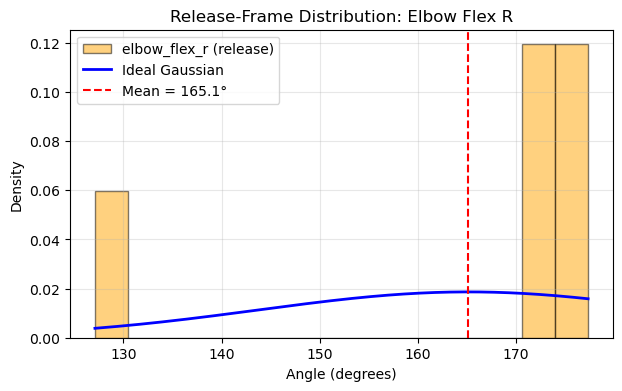

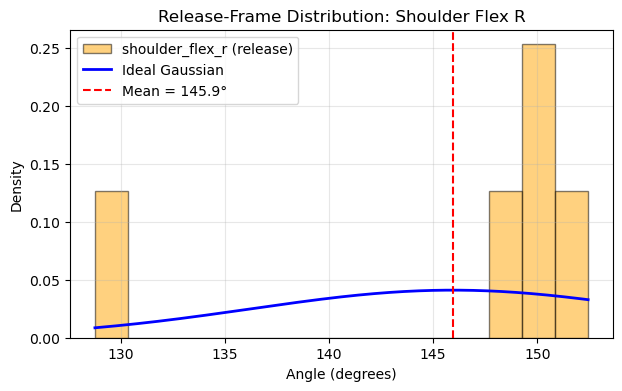

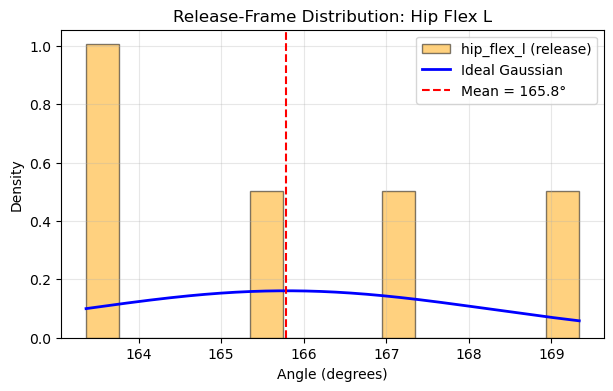

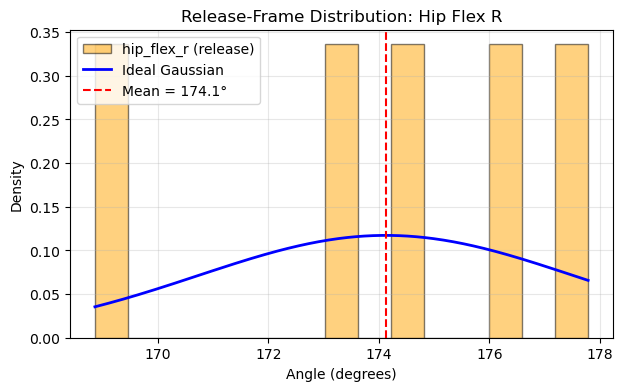

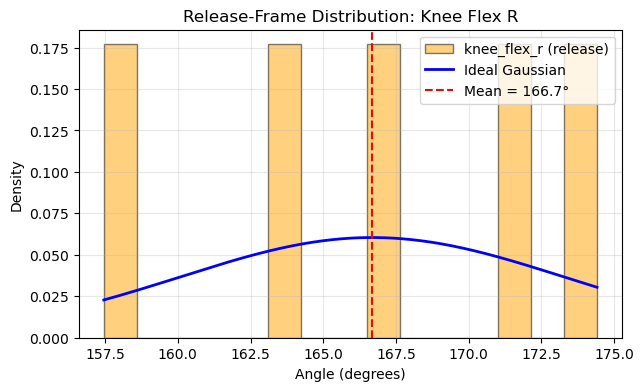

In [17]:
"""
DESCRIPTION:
    - Analyze distribution of joint angles at the release frame across all free throws.
    - Uses `phases_df['release_frame']` to find the exact frame for each clip.
    - Plots one histogram (with Gaussian overlay) per joint angle at release.
    - Saves summary statistics (mean, std, count) for all joints to CSV.
"""

release_summary_df = analyze_release_angles(
    cropped_angles_dfs,
    cropped_phases_df,
    metrics_path=metrics_dir, # TODO rename to _dir
    joints_to_plot=selected_joints,
    save_summary=False,
    display_summary=False
)

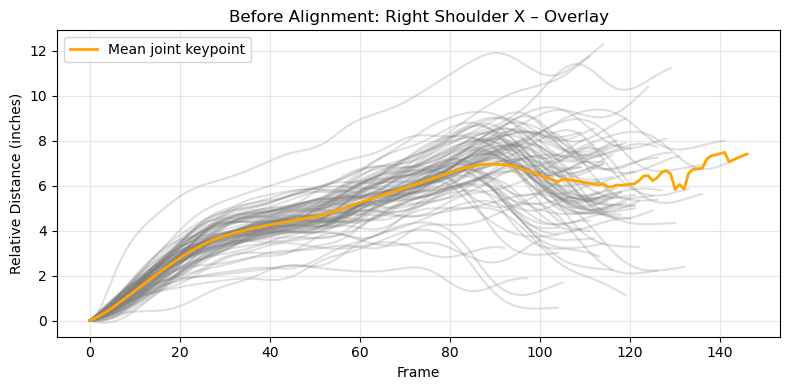

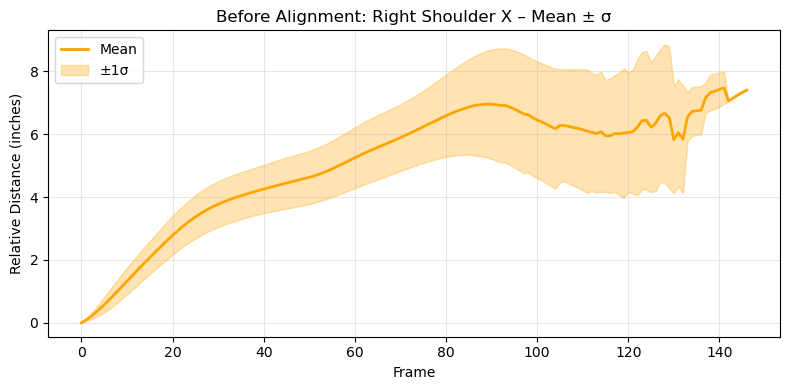

/Users/kwill55/RVL/personalized-sports-optimization/src/utils/visualize_freethrow_utils.py:70: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)


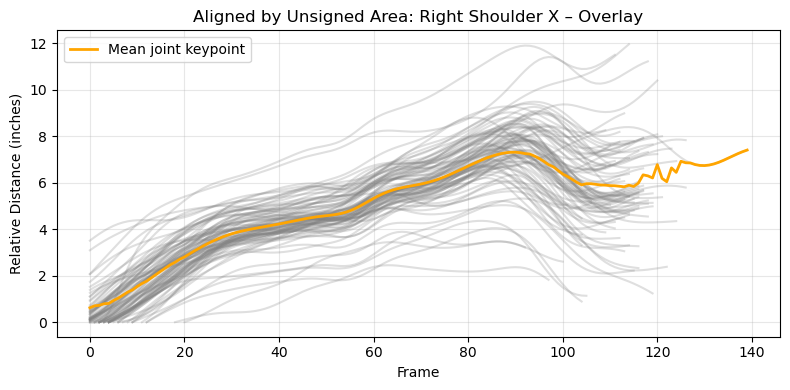

/Users/kwill55/RVL/personalized-sports-optimization/src/utils/visualize_freethrow_utils.py:101: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)
/opt/anaconda3/envs/RVL/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


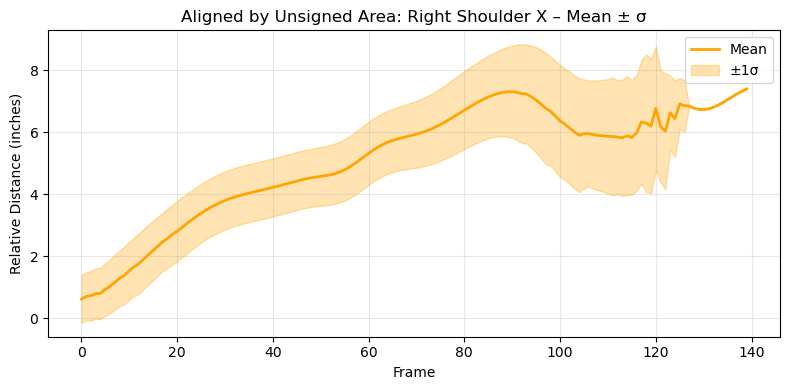

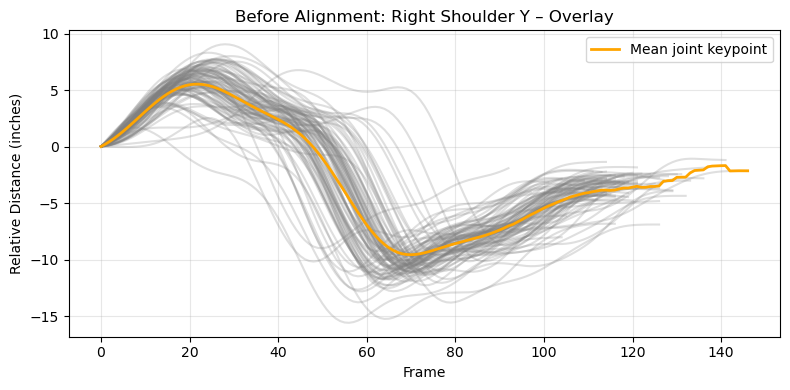

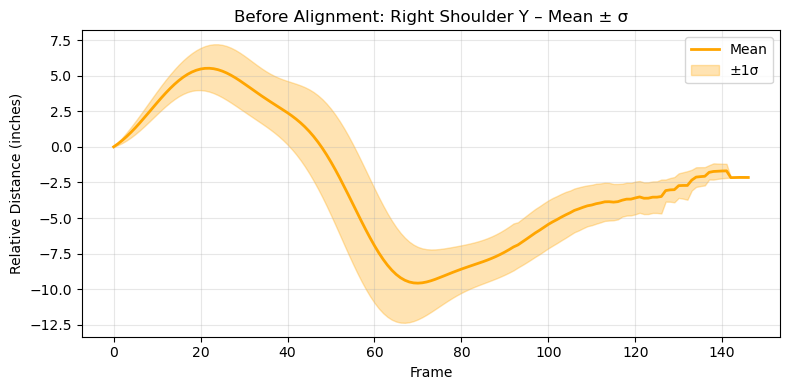

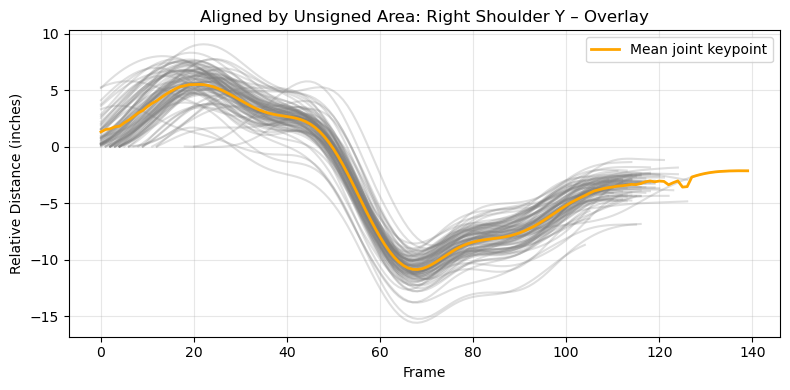

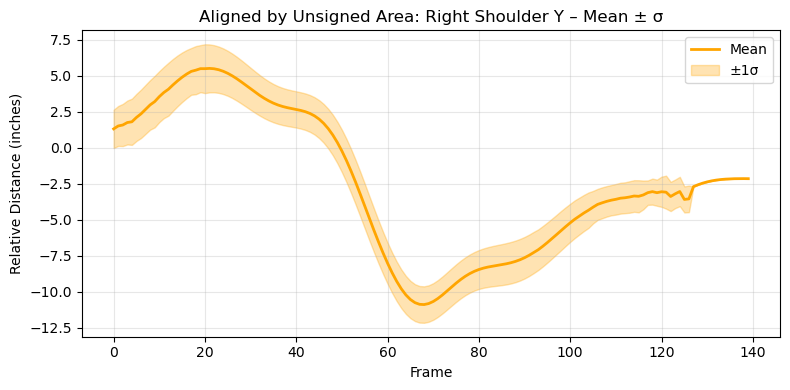

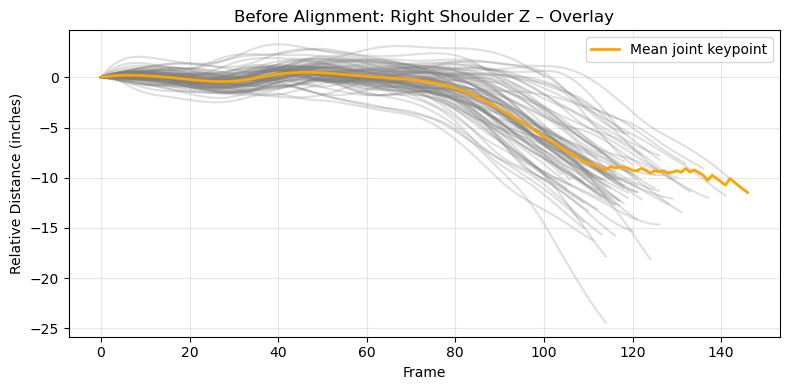

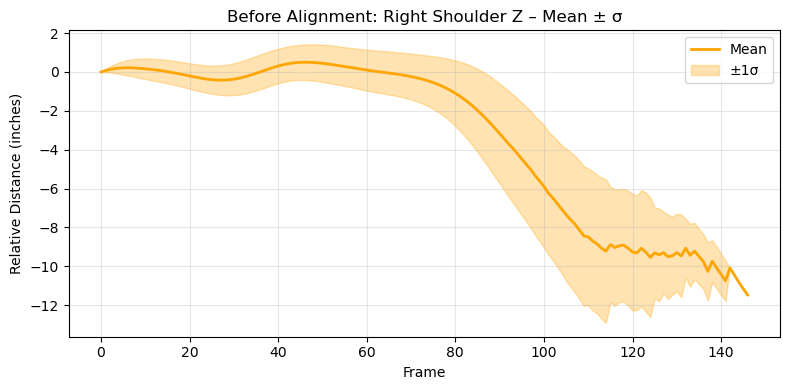

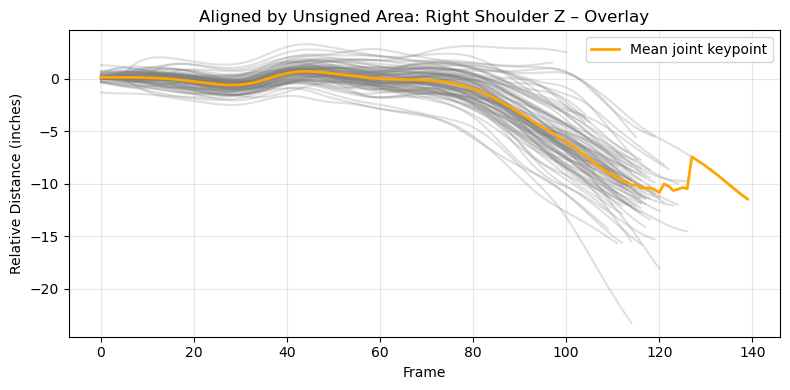

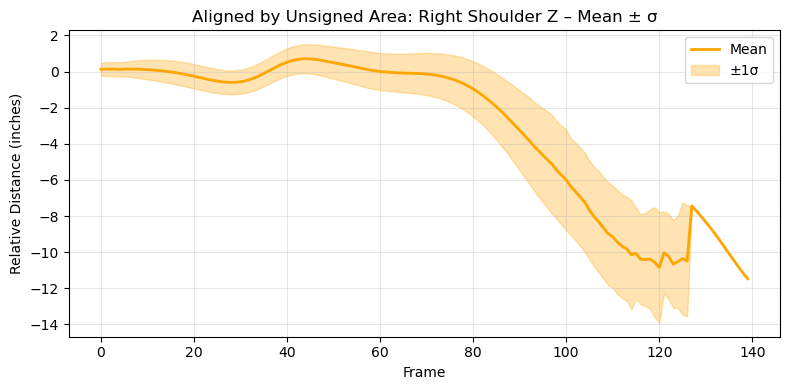

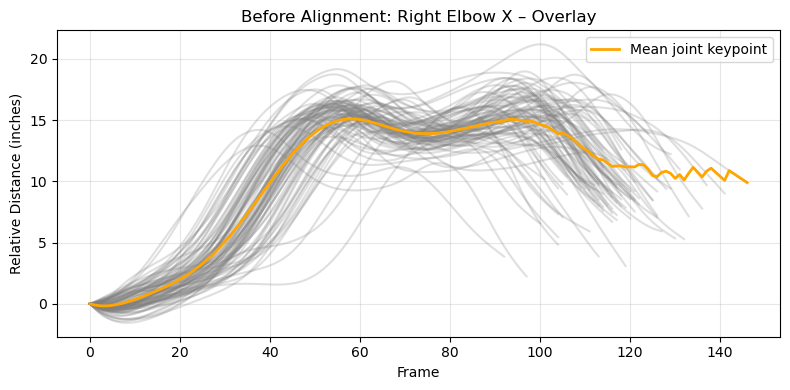

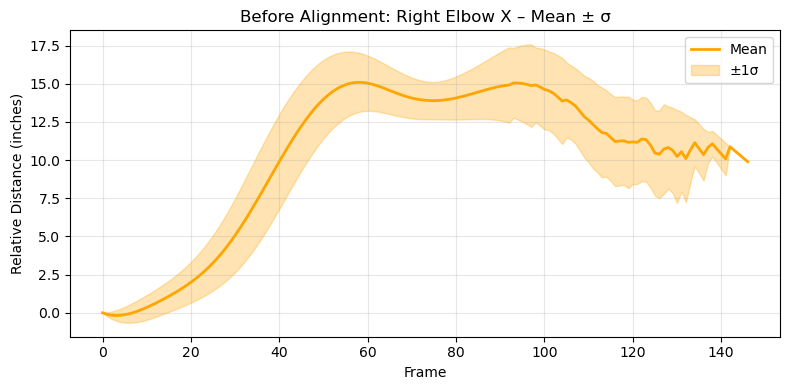

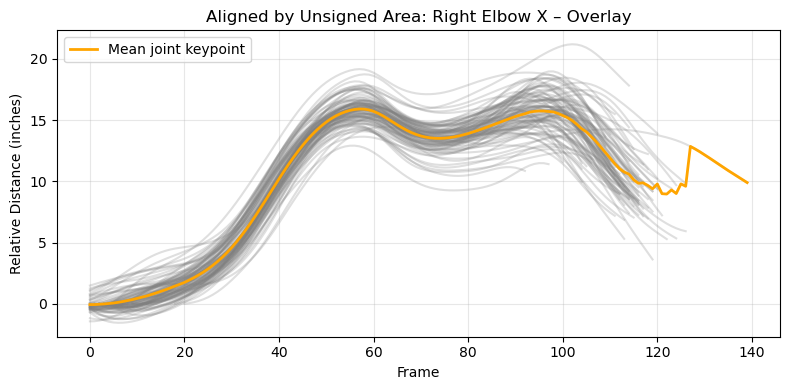

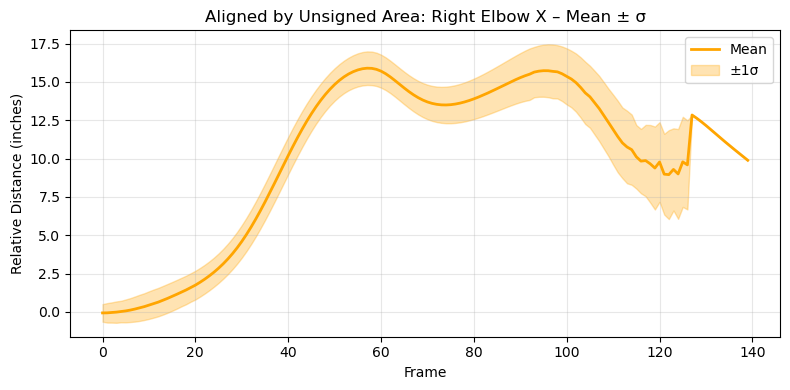

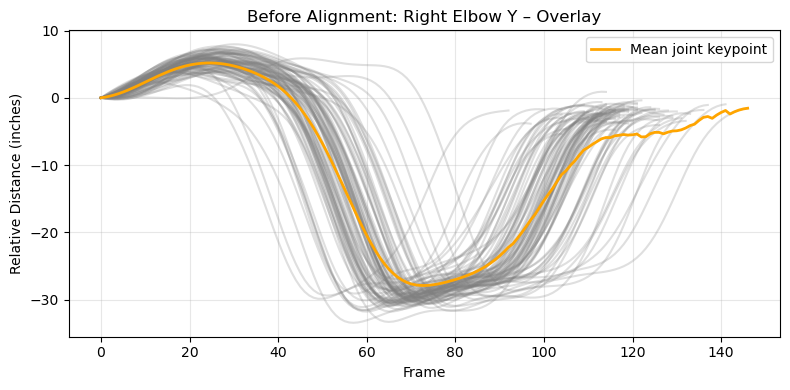

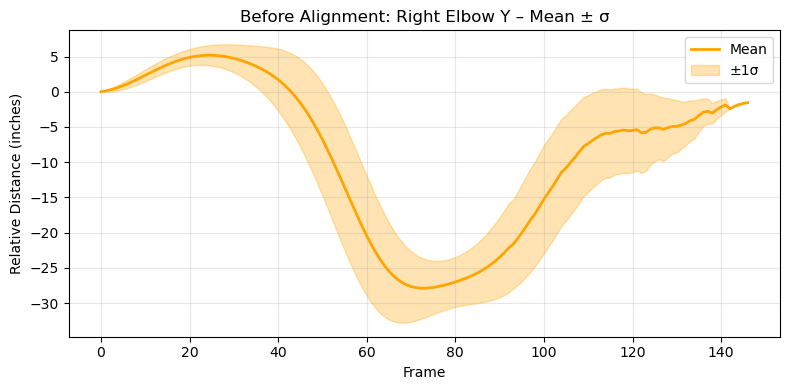

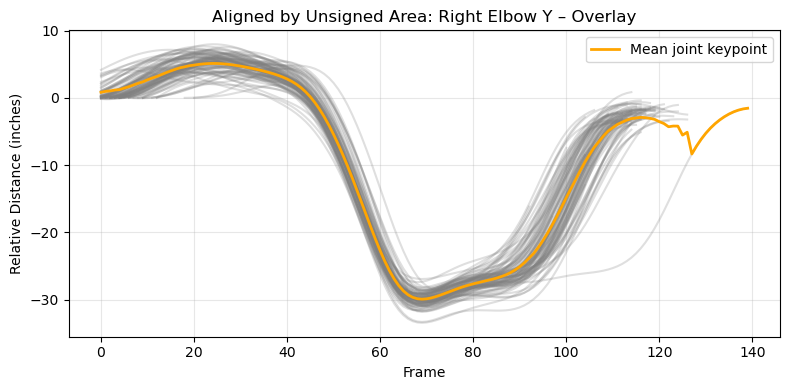

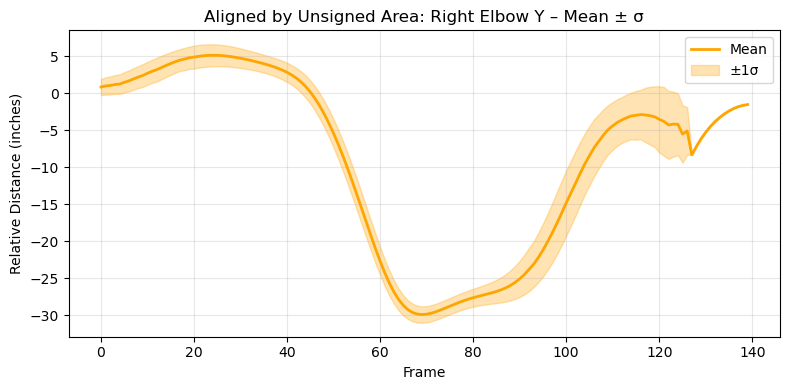

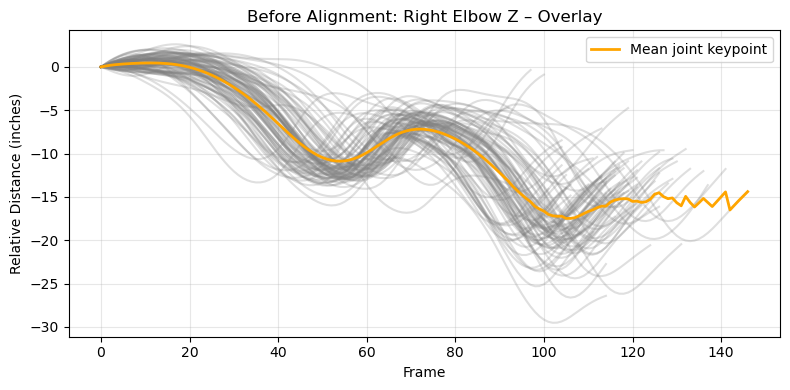

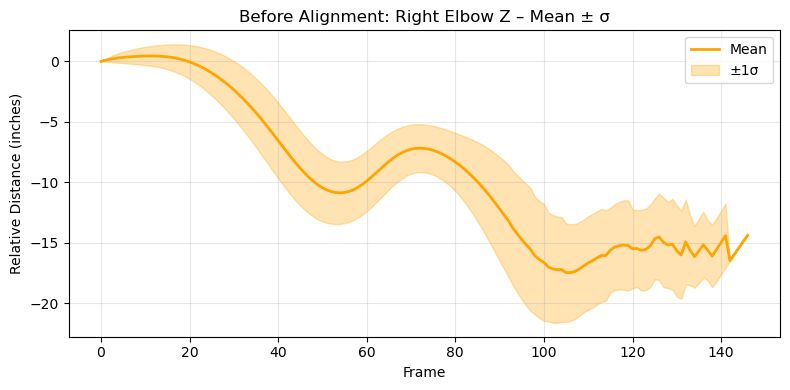

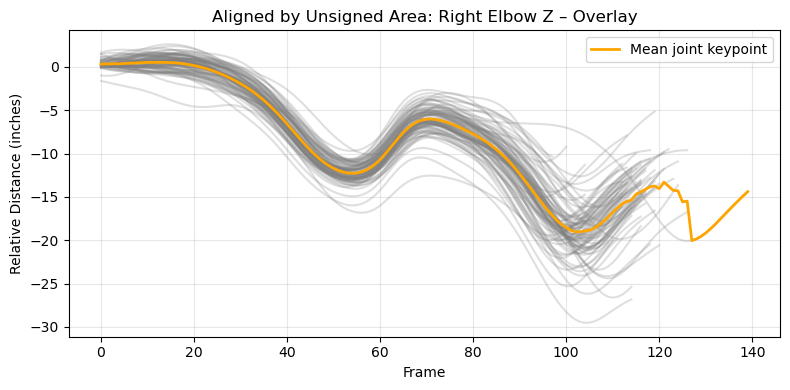

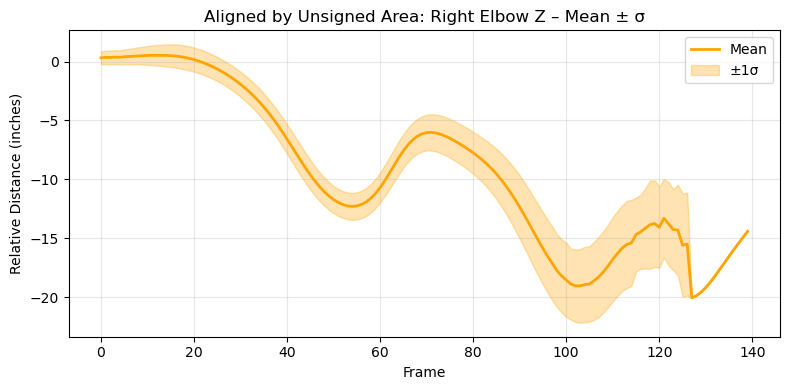

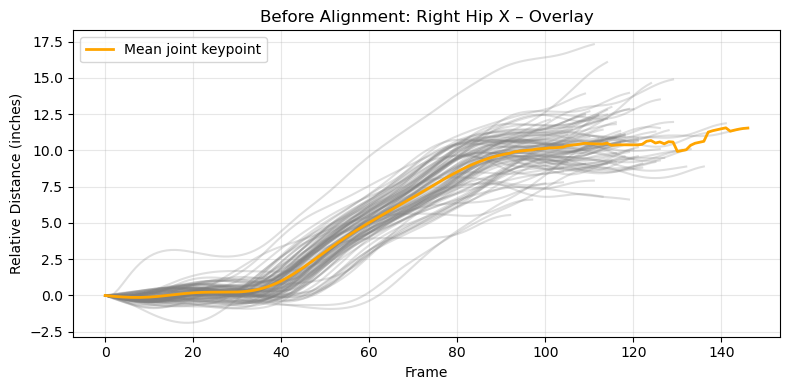

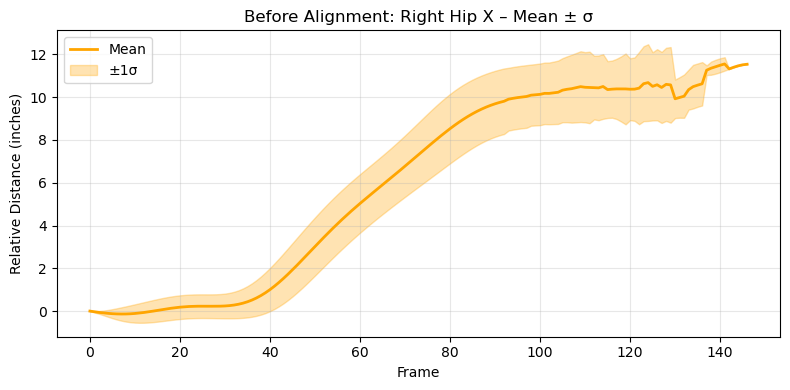

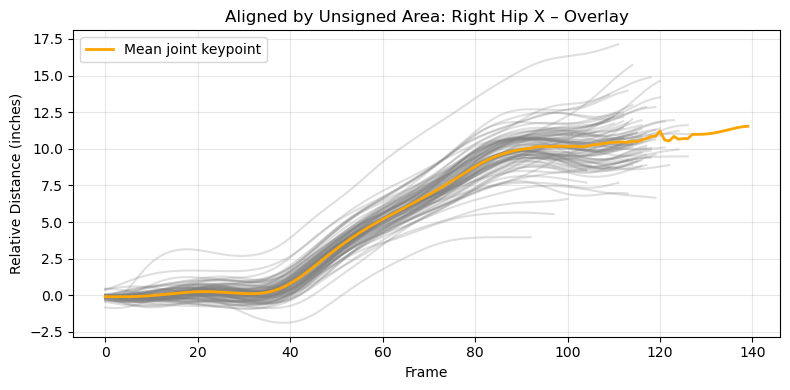

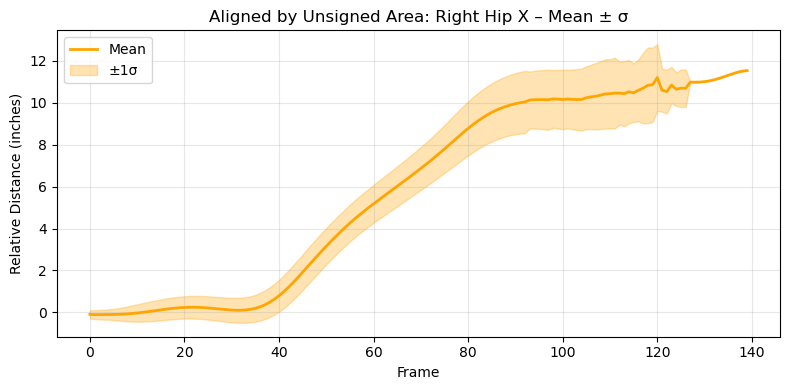

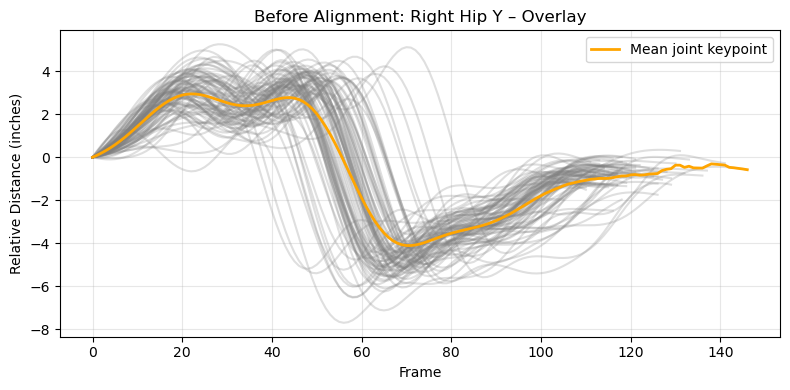

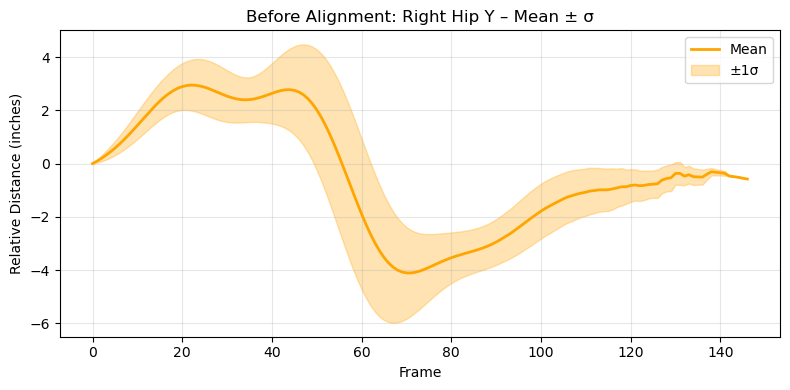

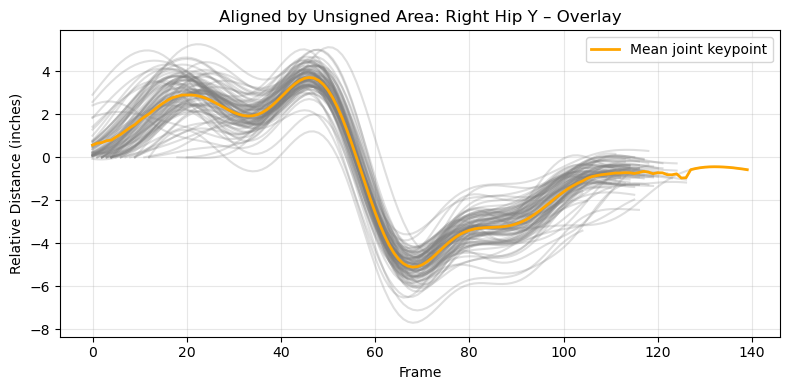

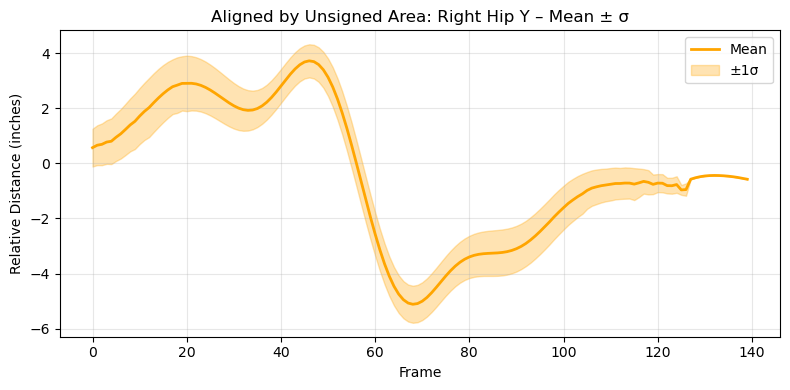

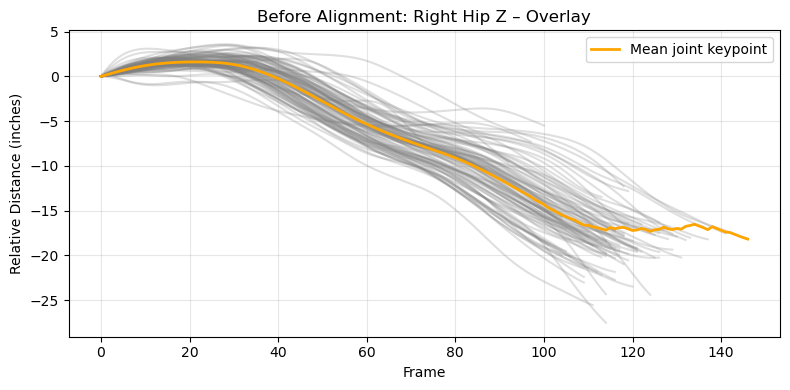

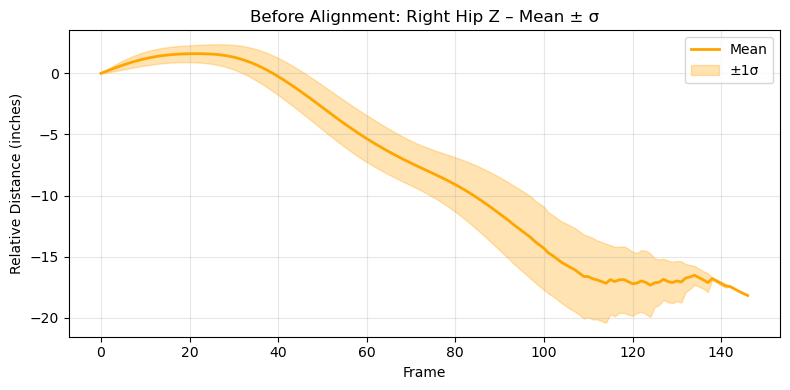

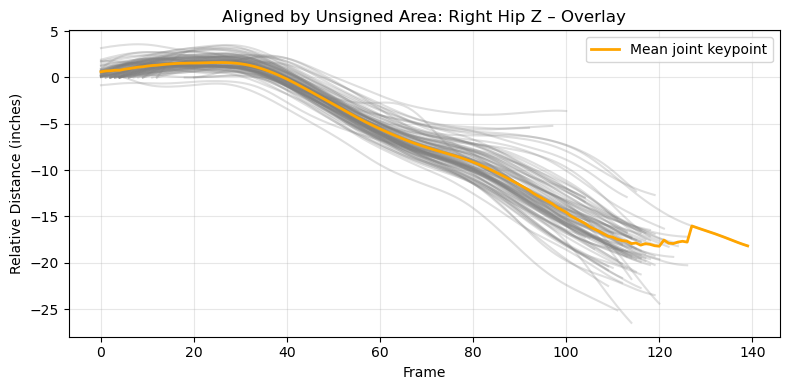

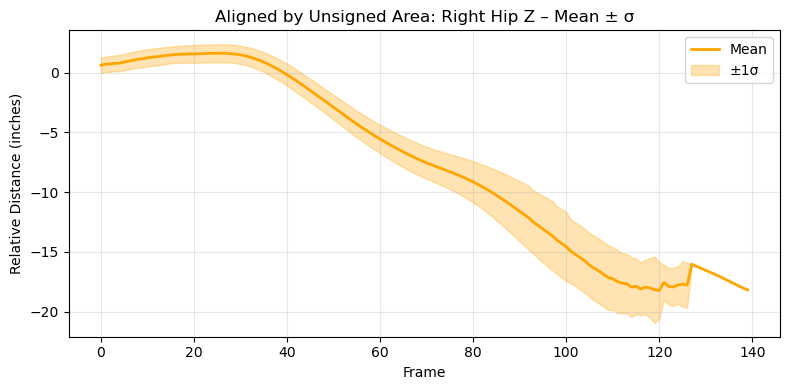

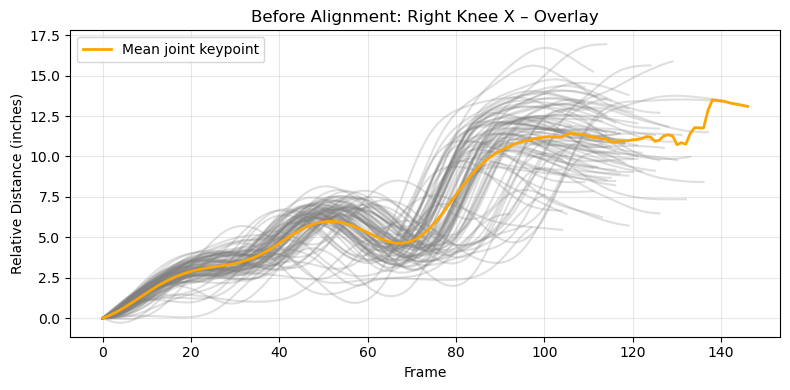

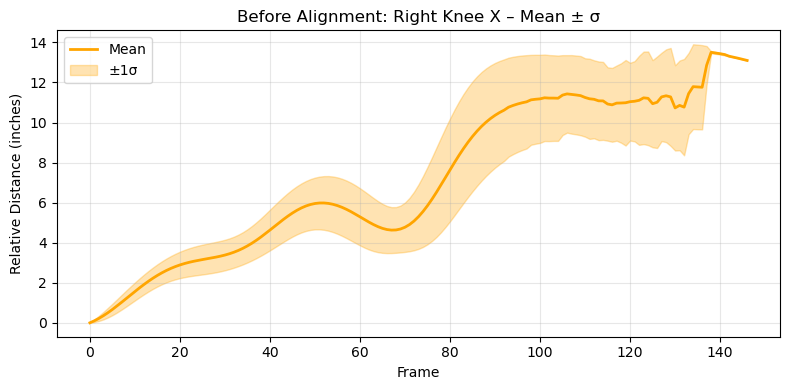

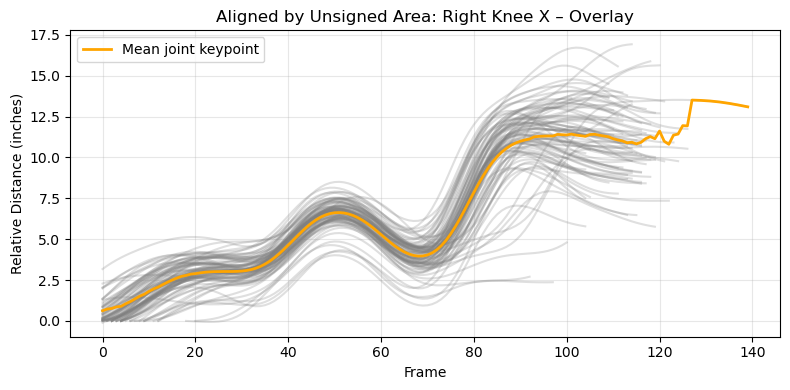

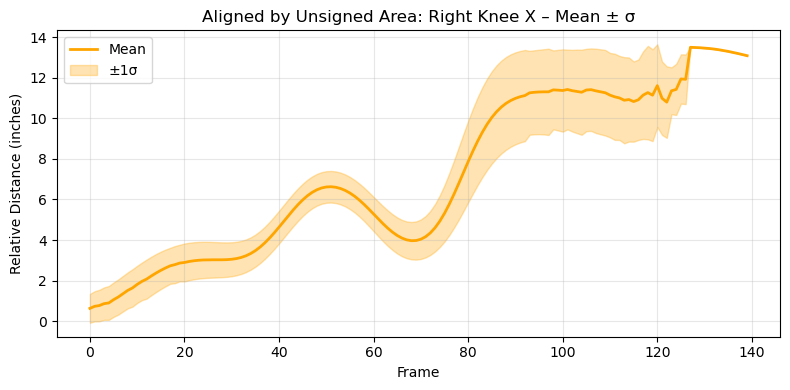

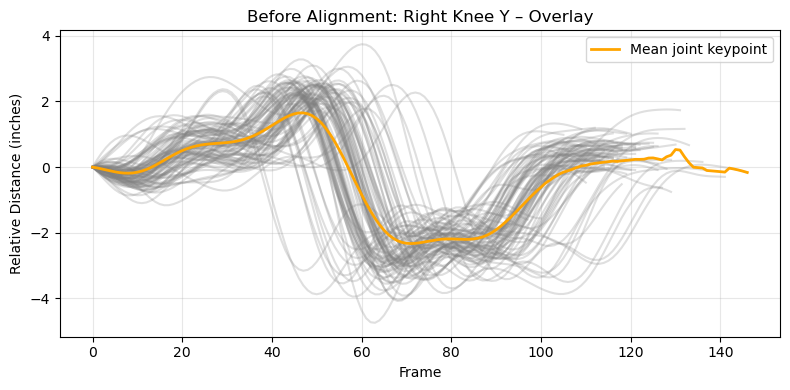

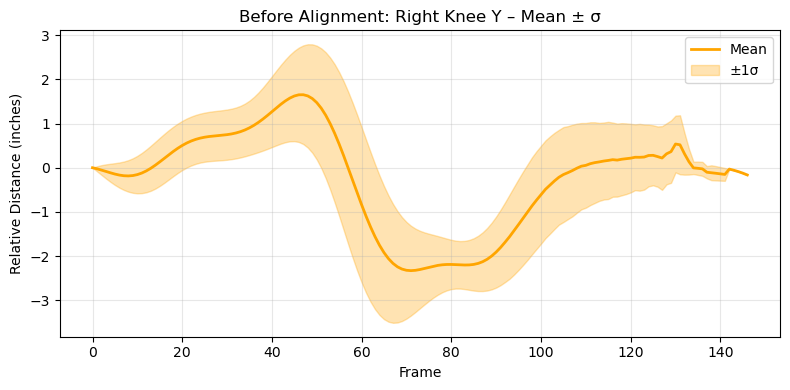

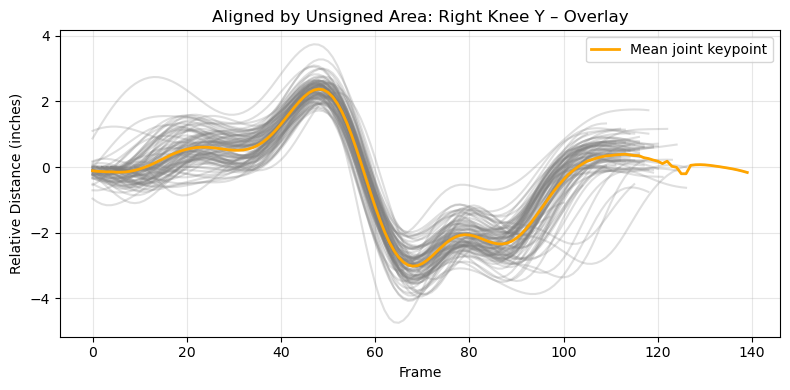

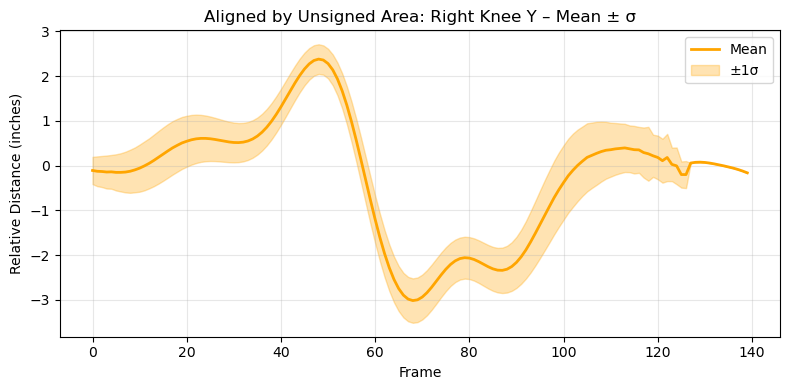

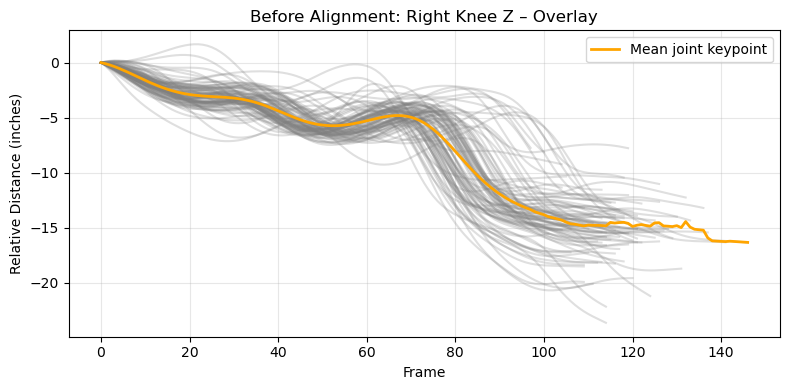

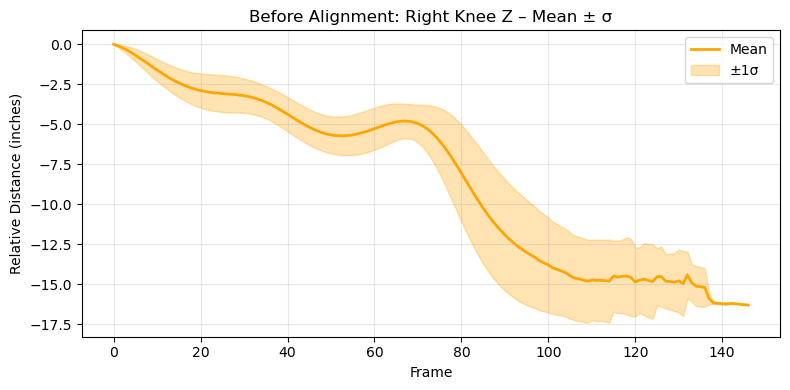

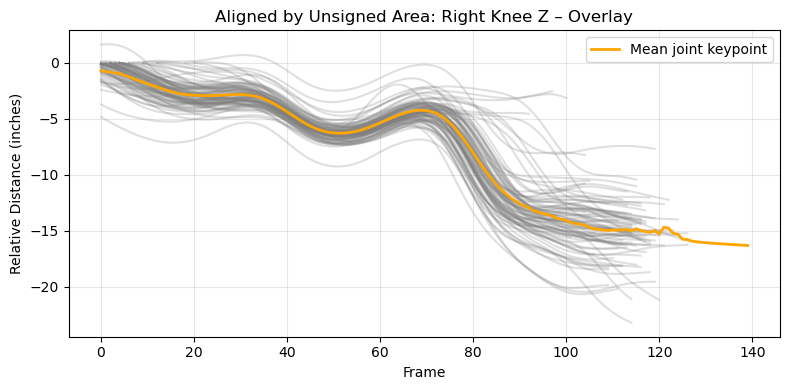

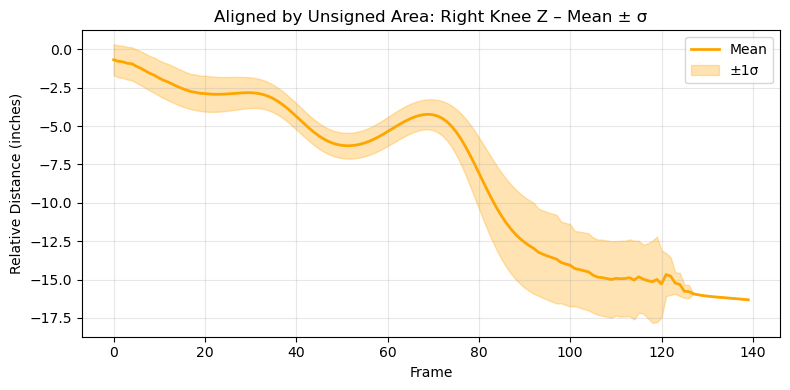

In [18]:
# Plot keypoint alignment 

PLOT_UNALIGNED_GRAPHS = True
PLOT_ALIGNED_RELEASE_FRAME_GRAPHS = False
PLOT_ALIGNED_UNSIGNED_AREA_GRAPHS = True 

# TODO eventually fix computer vision so that (0,0,0) is center of the body or something. For now we'll stick to relative measurements by zeroing out by subtracting the first frame  
# FIXME. making it relative mighthave broken it? or maybe its just zoomed in so looks slightly worse? 

viz = FreeThrowVisualizer(
    y_label="Relative Distance (inches)",
    title_label="Joint Keypoint"
)

for keypoint in selected_keypoints:

    if PLOT_UNALIGNED_GRAPHS:
        viz.plot_multiple_curves(
            cropped_relative_keypoints_dfs,
            [keypoint],
            dataset_name="Before Alignment",
            cropped_phases_df=cropped_phases_df,
            show_overlay=True,
            show_mean_std=False,
            show_release_line=False
        )

        viz.plot_multiple_curves(
            cropped_relative_keypoints_dfs,
            [keypoint],
            dataset_name="Before Alignment",
            cropped_phases_df=cropped_phases_df,
            show_overlay=False,
            show_mean_std=True,
            show_release_line=False
        )

    if PLOT_ALIGNED_RELEASE_FRAME_GRAPHS:
        viz.plot_multiple_curves(
            aligned_relative_keypoints_release_frame_dfs,
            [keypoint],
            dataset_name="Aligned by Release Frame",
            cropped_phases_df=cropped_phases_df,
            show_overlay=True,
            show_mean_std=False,
            show_release_line=False
        )

        viz.plot_multiple_curves(
            aligned_relative_keypoints_release_frame_dfs,
            [keypoint],
            dataset_name="Aligned by Release Frame",
            cropped_phases_df=cropped_phases_df,
            show_overlay=False,
            show_mean_std=True,
            show_release_line=False
        )

    if PLOT_ALIGNED_UNSIGNED_AREA_GRAPHS:
        viz.plot_multiple_curves(
            aligned_relative_keypoints_unsigned_area_dfs,
            [keypoint],
            dataset_name="Aligned by Unsigned Area",
            cropped_phases_df=cropped_phases_df,
            show_overlay=True,
            show_mean_std=False,
            show_release_line=False
        )

        viz.plot_multiple_curves(
            aligned_relative_keypoints_unsigned_area_dfs,
            [keypoint],
            dataset_name="Aligned by Unsigned Area",
            cropped_phases_df=cropped_phases_df,
            show_overlay=False,
            show_mean_std=True,
            show_release_line=False
        )



    # TODO display number of freethrows being displayed 
    # TODO make a grid of the four types of alignment
    # TODO fix the mess that is visualize_freethrow_utils.py

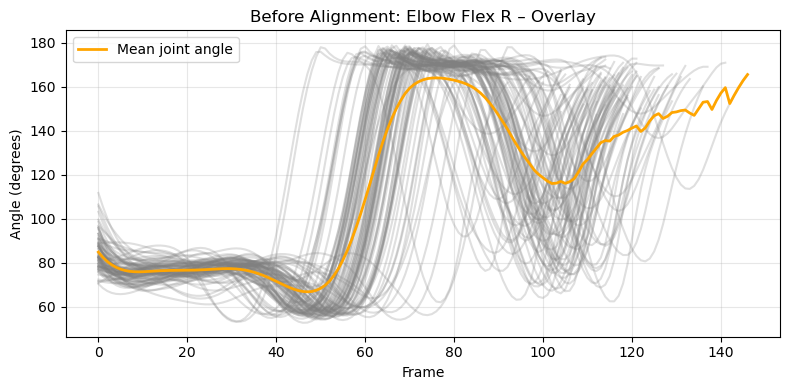

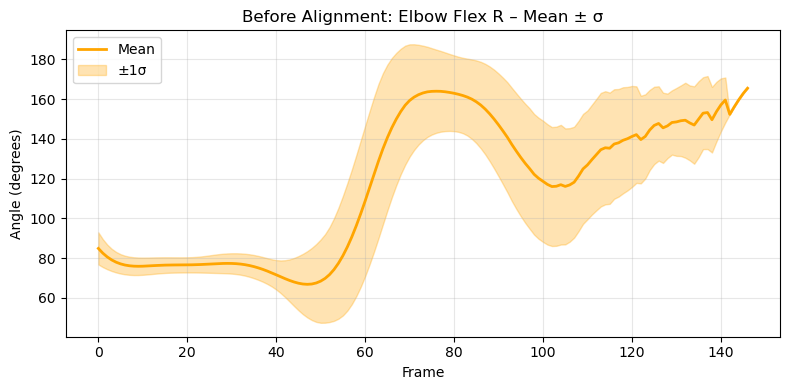

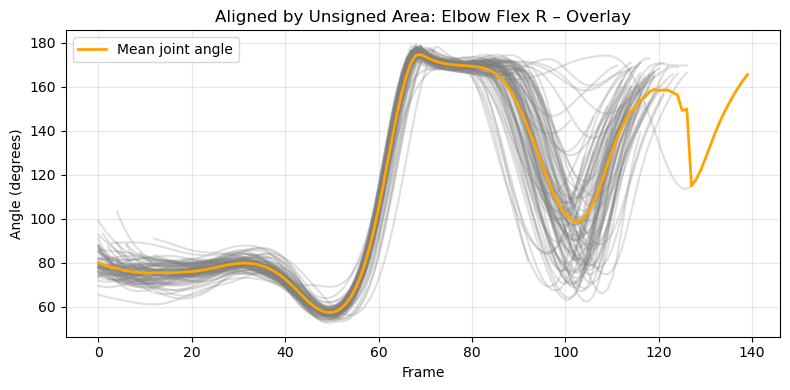

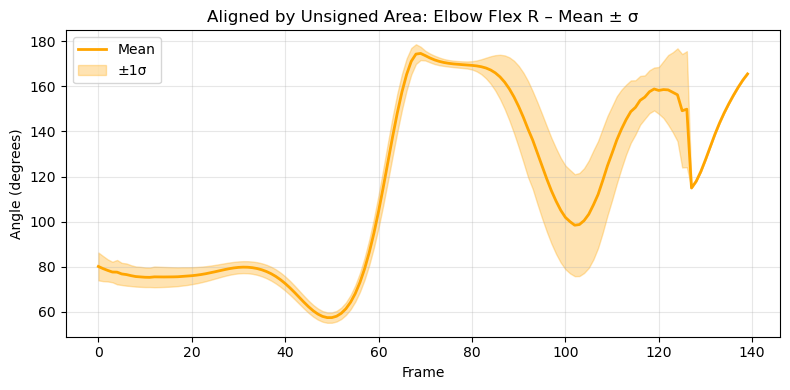

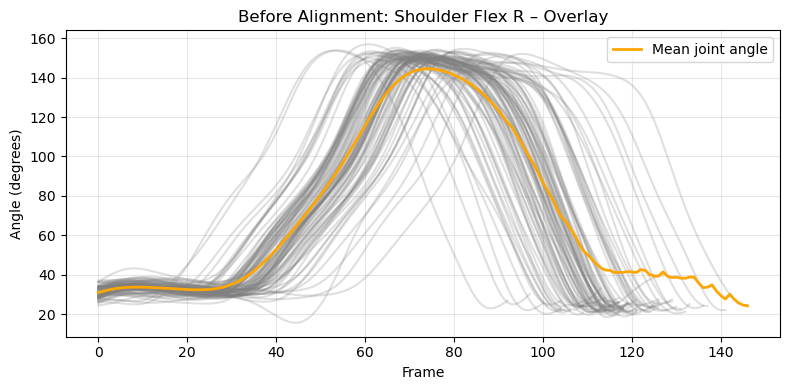

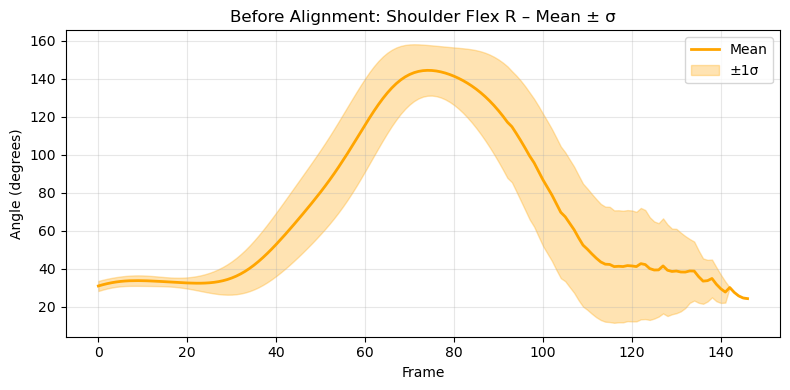

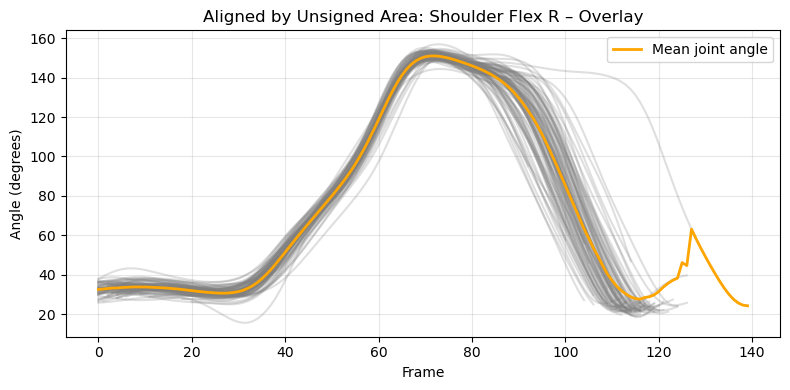

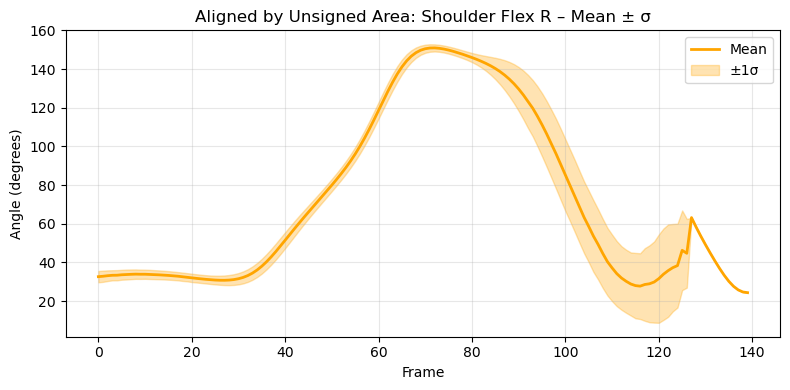

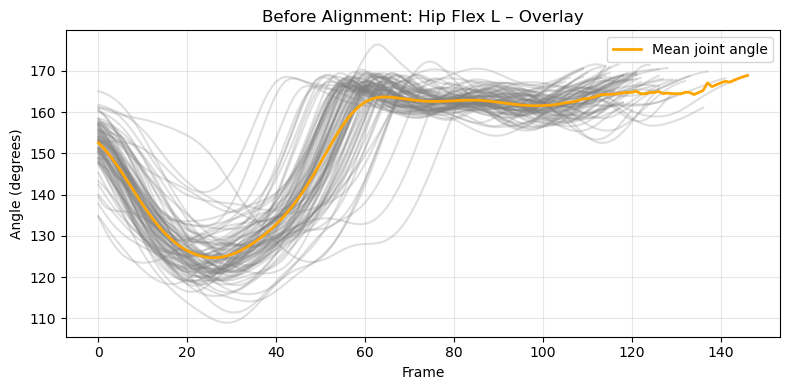

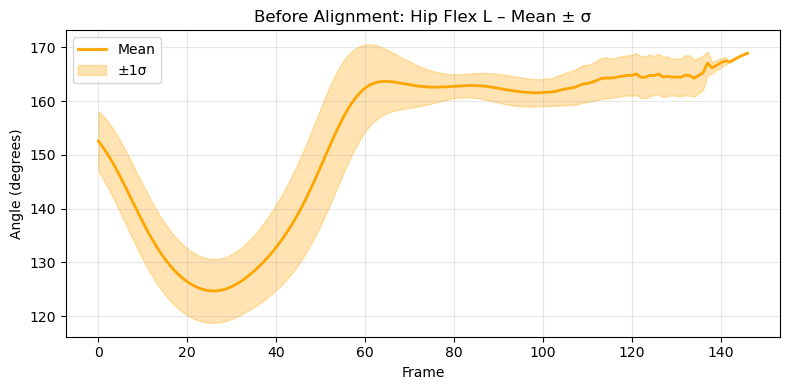

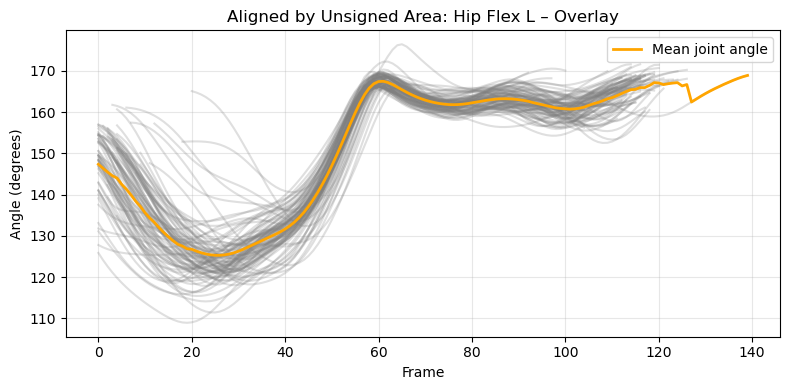

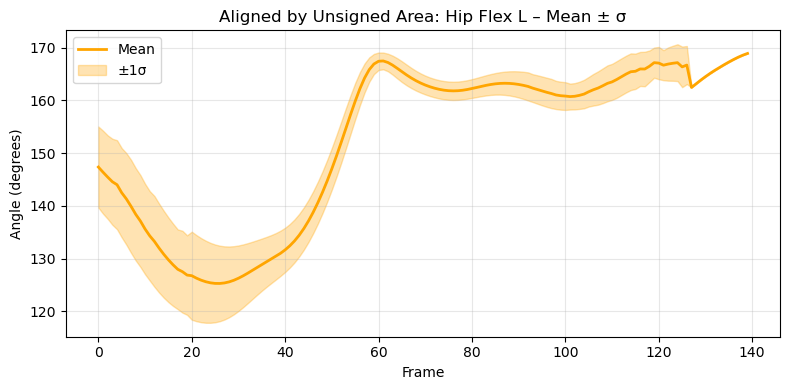

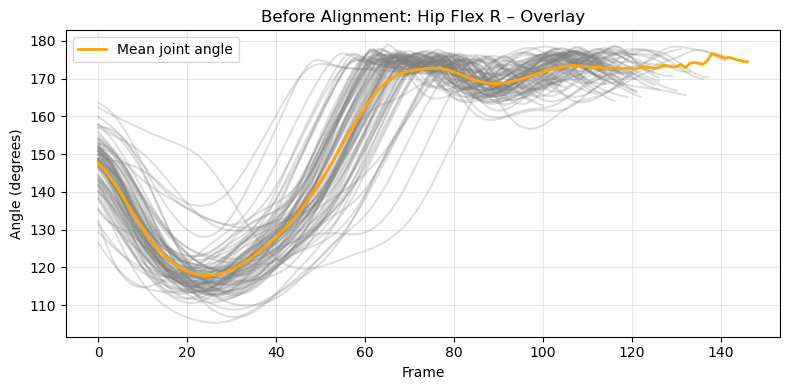

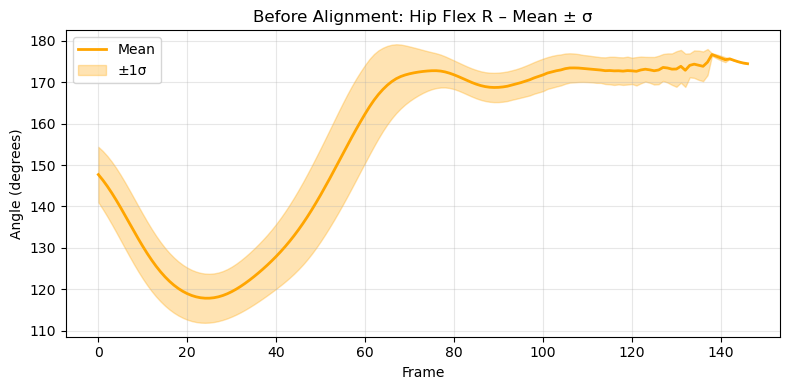

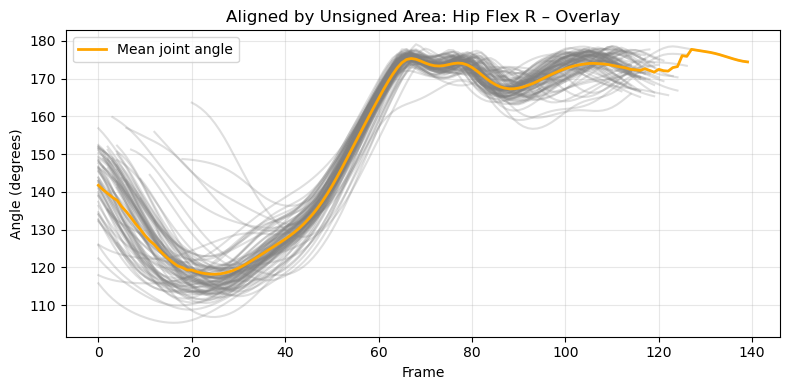

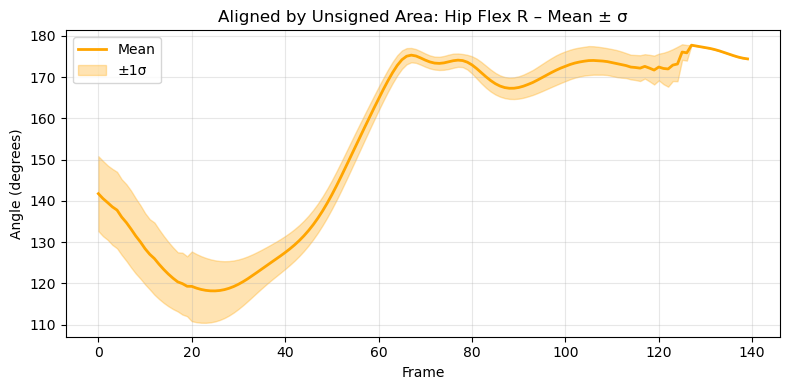

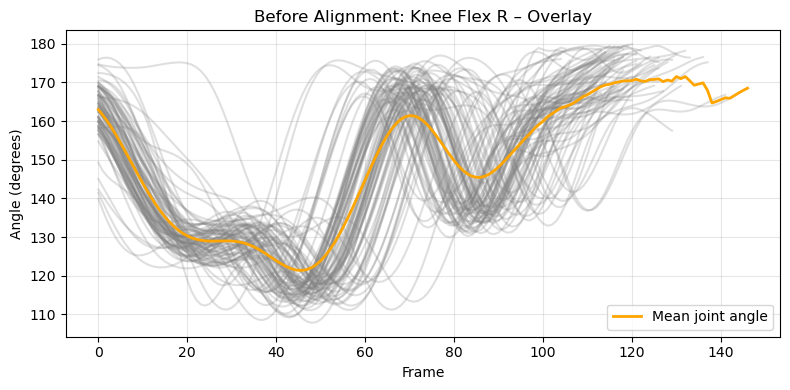

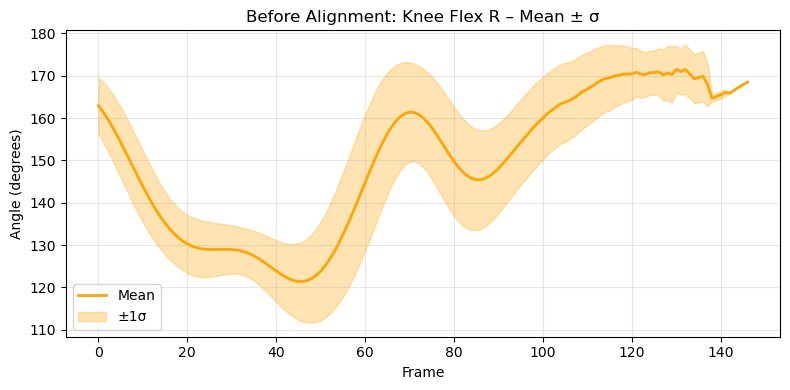

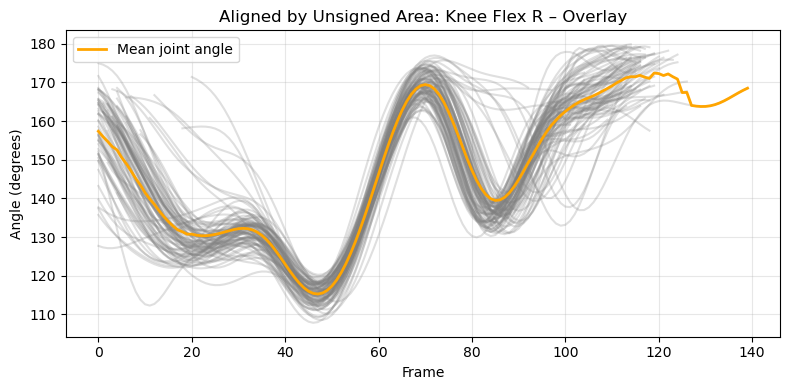

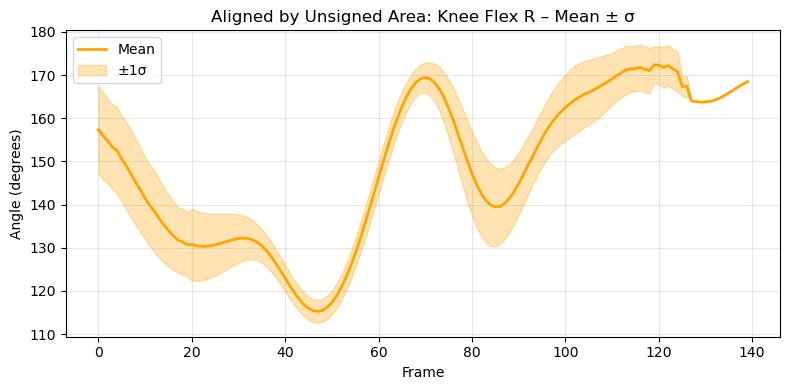

In [19]:
# Plot angle alignment 

PLOT_UNALIGNED_GRAPHS = True
PLOT_ALIGNED_LOWEST_FRAME_GRAPHS = False
PLOT_ALIGNED_RELEASE_FRAME_GRAPHS = False
PLOT_ALIGNED_UNSIGNED_AREA_GRAPHS = True
PLOT_ALIGNED_SIGNED_AREA_GRAPHS = False


viz = FreeThrowVisualizer(
    y_label="Angle (degrees)",
    title_label="Joint Angle"
)

for joint in selected_joints:

    if PLOT_UNALIGNED_GRAPHS:
        viz.plot_multiple_curves(
            cropped_angles_dfs,
            [joint],
            dataset_name="Before Alignment",
            cropped_phases_df=cropped_phases_df,
            show_overlay=True,
            show_mean_std=False,
            show_release_line=False
        )

        viz.plot_multiple_curves(
            cropped_angles_dfs,
            [joint],
            dataset_name="Before Alignment",
            cropped_phases_df=cropped_phases_df,
            show_overlay=False,
            show_mean_std=True,
            show_release_line=False
        )

    if PLOT_ALIGNED_LOWEST_FRAME_GRAPHS:
        viz.plot_multiple_curves(
            aligned_angles_lowest_frame_dfs,
            [joint],
            dataset_name="Aligned by Lowest Point",
            cropped_phases_df=cropped_phases_df,
            show_overlay=True,
            show_mean_std=False,
            show_release_line=False
        )

        viz.plot_multiple_curves(
            aligned_angles_lowest_frame_dfs,
            [joint],
            dataset_name="Aligned by Lowest Point",
            cropped_phases_df=cropped_phases_df,
            show_overlay=False,
            show_mean_std=True,
            show_release_line=False
        )

    if PLOT_ALIGNED_RELEASE_FRAME_GRAPHS:
        viz.plot_multiple_curves(
            aligned_angles_release_frame_dfs,
            [joint],
            dataset_name="Aligned by Release Frame",
            cropped_phases_df=cropped_phases_df,
            show_overlay=True,
            show_mean_std=False,
            show_release_line=False
        )

        viz.plot_multiple_curves(
            aligned_angles_release_frame_dfs,
            [joint],
            dataset_name="Aligned by Release Frame",
            cropped_phases_df=cropped_phases_df,
            show_overlay=False,
            show_mean_std=True,
            show_release_line=False
        )

    if PLOT_ALIGNED_UNSIGNED_AREA_GRAPHS:
        viz.plot_multiple_curves(
            aligned_angles_unsigned_area_dfs,
            [joint],
            dataset_name="Aligned by Unsigned Area",
            cropped_phases_df=cropped_phases_df,
            show_overlay=True,
            show_mean_std=False,
            show_release_line=False
        )

        viz.plot_multiple_curves(
            aligned_angles_unsigned_area_dfs,
            [joint],
            dataset_name="Aligned by Unsigned Area",
            cropped_phases_df=cropped_phases_df,
            show_overlay=False,
            show_mean_std=True,
            show_release_line=False
        )

    if PLOT_ALIGNED_SIGNED_AREA_GRAPHS:
        viz.plot_multiple_curves(
            aligned_angles_signed_area_dfs,
            [joint],
            dataset_name="Aligned by Signed Area",
            cropped_phases_df=cropped_phases_df,
            show_overlay=True,
            show_mean_std=False,
            show_release_line=False
        )

        viz.plot_multiple_curves(
            aligned_angles_signed_area_dfs,
            [joint],
            dataset_name="Aligned by Signed Area",
            cropped_phases_df=cropped_phases_df,
            show_overlay=False,
            show_mean_std=True,
            show_release_line=False
        )



    # TODO display number of freethrows being displayed 
    # TODO make a grid of the four types of alignment
    # TODO fix the mess that is visualize_freethrow_utils.py 





In [ ]:
viz = FreeThrowVisualizer(
    y_label="Distance",
    title_label="Keypoint Position"
)

viz.interactive_review(
    curve_name = "right_elbow_z",
    dfs_dict=aligned_relative_keypoints_unsigned_area_dfs,
    stats_dict=unsigned_area_keypoint_stats,
)


interactive(children=(IntSlider(value=0, description='Throw Index', max=88), Output()), _dom_classes=('widget-…

<function utils.visualize_freethrow_utils.FreeThrowVisualizer.interactive_review.<locals>.show(idx)>

In [22]:
viz = FreeThrowVisualizer(
    y_label="Angle (degrees)",
    title_label="Joint Angle"
)

viz.interactive_review(
    curve_name="hip_flex_l",
    dfs_dict=aligned_angles_unsigned_area_dfs,
    stats_dict=unsigned_area_angle_stats,
)

# TODO add percentage it stays within a certain region (but dont calculate this in visualize_freethrow_utils. this is only for visualization, not calculation)
# TODO add multiple standard deviations worth varying points (green for 1st std dev, yellow for 2nd, etc)


interactive(children=(IntSlider(value=0, description='Throw Index', max=88), Output()), _dom_classes=('widget-…

<function utils.visualize_freethrow_utils.FreeThrowVisualizer.interactive_review.<locals>.show(idx)>

In [23]:
"""
DESCRIPTION:
    - Plot mean ± σ trajectories (Option 1) and overlayed normalized trajectories (Option 2)
      for selected joints across all free throws.
    - Each throw is time-normalized to 0–100%.
    - Uses outcomes.csv to separate made vs missed shots.
"""

# === CONFIG ===
NUM_SAMPLES = 100
SHOW_MEAN_STD = True
SHOW_OVERLAY = True

# === Helper: normalize each throw to same number of samples ===
def normalize_series(series, num_points=NUM_SAMPLES):
    """Interpolate a 1D array to a fixed number of equally spaced points."""
    x_old = np.linspace(0, 1, len(series))
    x_new = np.linspace(0, 1, num_points)
    return np.interp(x_new, x_old, series)

# === Load outcomes file ===
outcomes_path = metrics_path / "outcomes.csv"
outcomes_df = pd.read_csv(outcomes_path)

# Clean and normalize names for matching
outcomes_df["file_base"] = (
    outcomes_df["file"]
    .str.replace(".avi", "", regex=False)
    .str.replace(".csv", "", regex=False)
    .str.strip()
    .str.lower()
)
outcomes_df["outcome"] = outcomes_df["outcome"].str.lower().str.strip()

# === Loop through selected joints ===
for joint_name, display_joint in joint_flags.items():
    if not display_joint:
        continue

    curves_make, curves_miss = [], []

    for file_name, df in cropped_angles_dfs.items():
        base_name = file_name.lower().strip()
        match = outcomes_df[outcomes_df["file_base"] == base_name]

        if match.empty or joint_name not in df.columns:
            continue

        y = df[joint_name].dropna().values
        if len(y) < 5:
            continue

        normalized = normalize_series(y)
        outcome = match["outcome"].iloc[0]

        if outcome == "made":
            curves_make.append(normalized)
        elif outcome == "missed" or outcome == "miss":
            curves_miss.append(normalized)

    if not curves_make and not curves_miss:
        print(f"[WARNING] No data for {joint_name}")
        continue

    x = np.linspace(0, 100, NUM_SAMPLES)

    # === Helper for mean/std ===
    def mean_std(curves):
        if len(curves) == 0:
            return None, None
        arr = np.vstack(curves)
        return arr.mean(axis=0), arr.std(axis=0)

    mean_make, std_make = mean_std(curves_make)
    mean_miss, std_miss = mean_std(curves_miss)

    # === Option 1 – Overlay all trajectories ===
    if SHOW_OVERLAY:
        plt.figure(figsize=(7, 4))

        # individual trajectories
        for y in curves_make:
            plt.plot(x, y, color="green", alpha=0.15)
        for y in curves_miss:
            plt.plot(x, y, color="red", alpha=0.15)

        # mean lines
        if mean_make is not None:
            plt.plot(x, mean_make, color="green", linewidth=2.5, label="Make (mean)")
        if mean_miss is not None:
            plt.plot(x, mean_miss, color="red", linewidth=2.5, label="Miss (mean)")

        plt.title(f"{joint_name.replace('_',' ').title()} – Normalized Trajectories")
        plt.xlabel("Normalized Motion (%)")
        plt.ylabel("Angle (°)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    # === Option 2 – Mean ± σ ===
    if SHOW_MEAN_STD:
        plt.figure(figsize=(7, 4))

        # Makes
        if mean_make is not None:
            plt.plot(x, mean_make, color="green", linewidth=2.5, label="Make (mean)")
            plt.fill_between(x, mean_make - std_make, mean_make + std_make,
                             color="green", alpha=0.25, label="Make ±1σ")

        # Misses
        if mean_miss is not None:
            plt.plot(x, mean_miss, color="red", linewidth=2.5, label="Miss (mean)")
            plt.fill_between(x, mean_miss - std_miss, mean_miss + std_miss,
                             color="red", alpha=0.25, label="Miss ±1σ")

        plt.title(f"{joint_name.replace('_',' ').title()} – Mean ± σ Consistency")
        plt.xlabel("Normalized Motion (%)")
        plt.ylabel("Angle (°)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    # === Print summary ===
    def describe(curves):
        if not curves:
            return "n/a"
        arr = np.vstack(curves)
        mean_val = arr.mean()
        std_val = arr.std()
        cv = (std_val / mean_val) * 100 if mean_val != 0 else 0
        return f"avg STD = {std_val:.2f}, CV = {cv:.1f}%"

    print(f"{joint_name}: {len(curves_make)} makes, {len(curves_miss)} misses")
    print(f"   Makes:  {describe(curves_make)}")
    print(f"   Misses: {describe(curves_miss)}\n")


NameError: name 'metrics_path' is not defined

In [ ]:
# === Multi-Joint Coordination Plot with Release Window + Peak Annotations ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- choose which joints to compare and whether to show faint overlays ---
COMPARE_JOINTS = ["knee_flex_r", "elbow_flex_r", "shoulder_flex_r"]
SHOW_INDIVIDUAL_OVERLAYS = True

# --- pick if you want to look for min/max for given angle ---
EXTREMUM = {
    "knee_flex_r": "min",      
    "knee_flex_l": "min",
    "elbow_flex_r": "max",
    "elbow_flex_l": "max",
    "shoulder_flex_r": "max",
    "shoulder_flex_l": "max",
    "hip_flex_r": "min",       
    "hip_flex_l": "min",
    "ankle_flex_r": "min",
    "ankle_flex_l": "min",
}

def extremum_index(curve, which="max"):
    return int(np.argmax(curve)) if which == "max" else int(np.argmin(curve))

# --- helper to collect normalized curves + mean/std for one joint ---
def collect_joint_curves(joint_name, num_points=100):
    curves = []
    for file_name, df in cropped_angles_dfs.items():
        if joint_name not in df.columns:
            continue
        y = df[joint_name].dropna().values
        if len(y) < 5:
            continue
        curves.append(normalize_series(y, num_points))
    if not curves:
        return None, None, None
    curves = np.vstack(curves)
    mean_curve = curves.mean(axis=0)
    std_curve  = curves.std(axis=0, ddof=1)
    return curves, mean_curve, std_curve

# --- compute normalized release % per throw (0–100%) ---
release_percents = []
for file_name, df in cropped_angles_dfs.items():
    base = file_name.split("_angles")[0]
    row = raw_phases_df[raw_phases_df["file"].str.contains(base, na=False)]
    if row.empty:
        continue
    ws, rel, fe = row[["raw_windup_start","raw_release_frame","followthrough_end"]].values[0]
    if pd.isna(ws) or pd.isna(rel) or pd.isna(fe):
        continue
    ws, rel, fe = int(ws), int(rel), int(fe)
    total = max(fe - ws, 1)
    pct = 100.0 * (rel - ws) / total
    # keep only sane values
    if np.isfinite(pct) and -50 <= pct <= 150:
        release_percents.append(pct)

if len(release_percents) == 0:
    print("[WARNING] No valid release timings found.")
    rel_mean, rel_std = 50.0, 0.0
else:
    rel_mean = float(np.mean(release_percents))
    rel_std  = float(np.std(release_percents, ddof=1))

# --- collect curves for requested joints ---
joint_mean_curves = {}
joint_std_curves  = {}
joint_all_curves  = {}

for j in COMPARE_JOINTS:
    curves, m, s = collect_joint_curves(j, NUM_SAMPLES)
    if curves is None:
        print(f"[⚠️] No data for {j}, skipping.")
        continue
    joint_all_curves[j]  = curves
    joint_mean_curves[j] = m
    joint_std_curves[j]  = s

# --- plot ---
x = np.linspace(0, 100, NUM_SAMPLES)
plt.figure(figsize=(9, 5))

# distinct colors for each joint
color_cycle = plt.cm.tab10(np.linspace(0, 1, max(3, len(joint_mean_curves))))
for i, j in enumerate(joint_mean_curves.keys()):
    color = color_cycle[i]
    # faint per-throw overlays (matching the joint color)
    if SHOW_INDIVIDUAL_OVERLAYS:
        for curve in joint_all_curves[j]:
            plt.plot(x, curve, color=color, alpha=0.06, linewidth=1)

    # mean line
    plt.plot(x, joint_mean_curves[j], color=color, linewidth=2.8,
             label=j.replace("_", " ").title())

# release mean (line) + ±1σ (span)
plt.axvline(rel_mean, linestyle="--", linewidth=1.5, color="black",
            label=f"Release ≈ {rel_mean:.0f}%")
if rel_std > 0:
    plt.axvspan(rel_mean - rel_std, rel_mean + rel_std, color="black", alpha=0.08,
                label="Release ±1σ")

plt.title("Multi-Joint Coordination: Mean Trajectories")
plt.xlabel("Normalized Motion (%)")
plt.ylabel("Angle (degrees)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- annotate peaks and print timing table vs release ---
print("\nPeak timing (mean trajectory) and delta to release:")
peak_marks = []
for i, j in enumerate(joint_mean_curves.keys()):
    curve = joint_mean_curves[j]
    which = EXTREMUM.get(j, "max")
    idx = extremum_index(curve, which)
    t_peak = x[idx]
    val    = curve[idx]
    peak_marks.append((j, t_peak, val, which))

# pretty print
for j, t_peak, val, which in peak_marks:
    print(f"• {j.replace('_',' ').title():16s} peak({which:3s}) at {t_peak:5.1f}%"
          f"  | value {val:6.1f}°  | change to release {t_peak - rel_mean:+5.1f}%")

# (optional) re-draw just the markers on top of the last figure:
plt.figure(figsize=(9, 5))
for i, j in enumerate(joint_mean_curves.keys()):
    color = color_cycle[i]
    plt.plot(x, joint_mean_curves[j], color=color, linewidth=2.8,
             label=j.replace("_", " ").title())
    # marker
    which = EXTREMUM.get(j, "max")
    idx = extremum_index(joint_mean_curves[j], which)
    plt.scatter([x[idx]], [joint_mean_curves[j][idx]], color=color, s=35, zorder=5)

plt.axvline(rel_mean, linestyle="--", linewidth=1.5, color="black",
            label=f"Release ≈ {rel_mean:.0f}%")
if rel_std > 0:
    plt.axvspan(rel_mean - rel_std, rel_mean + rel_std, color="black", alpha=0.08,
                label="Release ±1σ")

plt.title("Multi-Joint Coordination with Peaks + Release Window")
plt.xlabel("Normalized Motion (%)")
plt.ylabel("Angle (degrees)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


KeyError: "['followthrough_end'] not in index"